In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# =====================================
# 📘 SVM Baseline Model (No SMOTE)
# =====================================

# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from collections import Counter


In [3]:
# =====================================
# Cell 2: Load Dataset
# =====================================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [4]:
# =====================================
# Cell 3: Split Features
# =====================================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

print("\nClass distribution in train:", Counter(y_train))
print("Class distribution in test:", Counter(y_test))


Class distribution in train: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})
Class distribution in test: Counter({5: 32201, 4: 18265, 1: 16078, 2: 8376, 3: 7486})


In [5]:
# =====================================
# Cell 4: 10-Fold Cross Validation (Train) + Mean ± SD
# =====================================
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import time, os

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []
results = []

print("\n=== 10-Fold Cross Validation Results ===")
classes = sorted(np.unique(y_train))
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    base_svm = LinearSVC(random_state=42, dual=False, max_iter=2000)
    model = CalibratedClassifierCV(base_svm, cv=5)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')
    y_val_bin = label_binarize(y_val, classes=classes)
    auc_val = roc_auc_score(y_val_bin, y_prob, average='macro', multi_class='ovr')

    results.append([fold, acc, prec, rec, f1, auc_val])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(auc_val)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, "
          f"F1={f1:.3f}, AUC={auc_val:.3f}")

# 🧾 สรุปตารางผลแต่ละ fold
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print("\n" + cv_df.to_string(index=False))

# 📈 คำนวณ Mean ± SD
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# 📊 แสดงผลรวม
print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")




=== 10-Fold Cross Validation Results ===
Fold 1: Accuracy=0.679, Precision=0.586, Recall=0.679, F1=0.609, AUC=0.876
Fold 2: Accuracy=0.681, Precision=0.591, Recall=0.681, F1=0.612, AUC=0.878
Fold 3: Accuracy=0.680, Precision=0.599, Recall=0.680, F1=0.610, AUC=0.876
Fold 4: Accuracy=0.682, Precision=0.597, Recall=0.682, F1=0.613, AUC=0.875
Fold 5: Accuracy=0.679, Precision=0.587, Recall=0.679, F1=0.610, AUC=0.876
Fold 6: Accuracy=0.678, Precision=0.590, Recall=0.678, F1=0.610, AUC=0.877
Fold 7: Accuracy=0.677, Precision=0.583, Recall=0.677, F1=0.608, AUC=0.876
Fold 8: Accuracy=0.679, Precision=0.583, Recall=0.679, F1=0.610, AUC=0.877
Fold 9: Accuracy=0.681, Precision=0.586, Recall=0.681, F1=0.612, AUC=0.878
Fold 10: Accuracy=0.680, Precision=0.585, Recall=0.680, F1=0.611, AUC=0.876

 Fold  Accuracy  Precision   Recall       F1  AUC_ROC
    1  0.678822   0.586275 0.678822 0.609361 0.876301
    2  0.680976   0.590985 0.680976 0.611925 0.878411
    3  0.679914   0.598995 0.679914 0.610428

In [6]:
# 💾 (Optional) บันทึก Mean ± SD ลงไฟล์ CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/'
summary_path = base_path + "SVM_MeanSD.csv"

# ✅ ตรวจสอบและสร้างโฟลเดอร์อัตโนมัติ
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/SVM_MeanSD.csv


In [7]:
# =====================================
# Cell 5: Final Testing & Report
# =====================================
base_svm = LinearSVC(random_state=42, dual=False, max_iter=2000)
model = CalibratedClassifierCV(base_svm, cv=5)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_prob_test = model.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
y_test_bin = label_binarize(y_test, classes=classes)
test_auc = roc_auc_score(y_test_bin, y_prob_test, average="macro", multi_class="ovr")

print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, "
      f"F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)


📈 Test Set Metrics:
Accuracy: 0.680, Precision: 0.593, Recall: 0.680, F1: 0.611, AUC: 0.878

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.91      0.78     16078
           2       0.41      0.01      0.02      8376
           3       0.00      0.00      0.00      7486
           4       0.48      0.59      0.53     18265
           5       0.80      0.95      0.87     32201

    accuracy                           0.68     82406
   macro avg       0.47      0.49      0.44     82406
weighted avg       0.59      0.68      0.61     82406

Confusion Matrix:
[[14573    51     0  1335   119]
 [ 4630   107     0  3463   176]
 [ 1587    47     0  5343   509]
 [  606    51     0 10788  6820]
 [   46     6     0  1603 30546]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


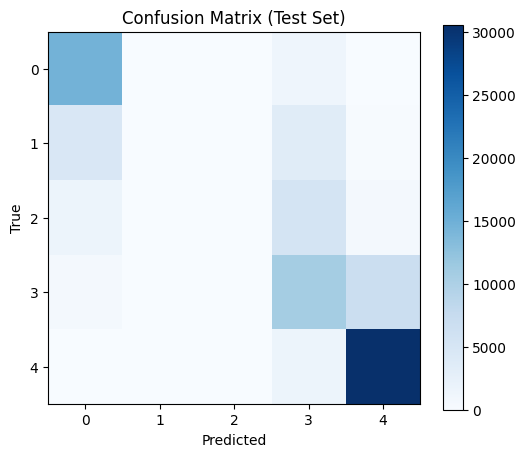

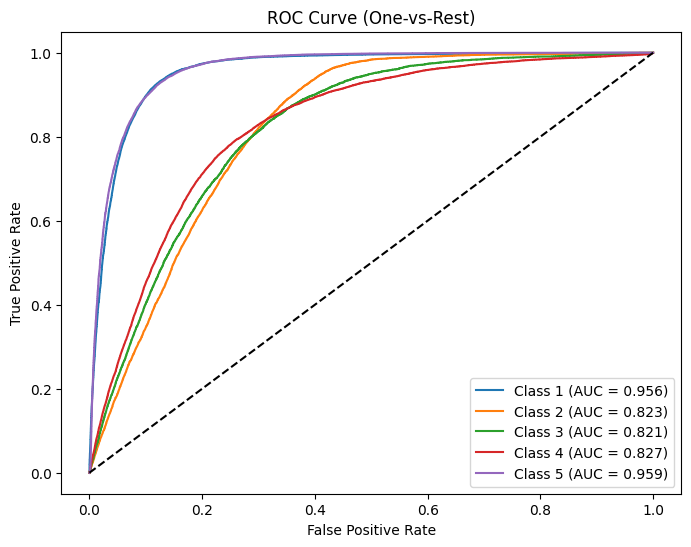

In [8]:
# =====================================
# Cell 6: Confusion Matrix & ROC
# =====================================
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# =====================================
# Cell 7: Save Model, AUC & ROC Data
# =====================================
base_path = '/content/drive/MyDrive/Senior_Project/roc/'

joblib.dump(model, base_path + 'svm_baseline.pkl')
print(f"\n💾 Model saved as {base_path}svm_baseline.pkl")

auscsv = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auscsv.to_csv(base_path + 'svm_baseline_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}svm_baseline_auc.csv")

roc_data = []
for i in range(len(classes)):
    df_temp = pd.DataFrame({
        'Class': [classes[i]] * len(fpr[i]),
        'FPR': fpr[i],
        'TPR': tpr[i]
    })
    roc_data.append(df_temp)

roc_df = pd.concat(roc_data, ignore_index=True)
roc_df.to_csv(base_path + 'svm_baseline_roc_data.csv', index=False)
print(f"💾 ROC curve data saved to {base_path}svm_baseline_roc_data.csv")


💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/svm_baseline.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/svm_baseline_auc.csv
💾 ROC curve data saved to /content/drive/MyDrive/Senior_Project/roc/svm_baseline_roc_data.csv
